## Quasi Periodic Eruptions – Extracting

### Definition Preamble

In [1]:
import xml.etree.ElementTree as ET
from svgpathtools import parse_path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_flattened_paths(svg_file_path):
    tree = ET.parse(svg_file_path)
    root = tree.getroot()
    
    for el in root.iter():
        if '}' in el.tag:
            el.tag = el.tag.split('}', 1)[1]

    flattened_elements = []

    def walk_tree(element, current_matrix):
        from svgpathtools.parser import parse_transform
        
        transform_str = element.get('transform', '')
        local_matrix = parse_transform(transform_str) if transform_str else np.identity(3)
        new_matrix = current_matrix @ local_matrix

        if element.tag == 'path':
            d_string = element.get('d', '')
            if d_string:
                path_obj = parse_path(d_string)
                
                a, c, e = new_matrix[0]
                b, d, f = new_matrix[1]
                
                transformed_segments = []
                for segment in path_obj:
                    s_real = a * segment.start.real + c * segment.start.imag + e
                    s_imag = b * segment.start.real + d * segment.start.imag + f
                    e_real = a * segment.end.real + c * segment.end.imag + e
                    e_imag = b * segment.end.real + d * segment.end.imag + f
                    
                    segment.start = complex(s_real, s_imag)
                    segment.end = complex(e_real, e_imag)
                    transformed_segments.append(segment)
                
                flattened_elements.append((path_obj, element.attrib))
        
        for child in element:
            walk_tree(child, new_matrix)

    walk_tree(root, np.identity(3))
    return flattened_elements

def extract_curve(svg_file_path):
    all_paths = get_flattened_paths(svg_file_path)
    identifiers = ['#000000', 'rgb(0,0,0)', 'rgb(0, 0, 0)']
    points = []

    for path, attr in all_paths:
        style = str(attr.get('style', '')).lower()
        stroke = str(attr.get('stroke', '')).lower()
        fill = str(attr.get('fill', '')).lower()
        combined = f"{style} {stroke} {fill}"

        if not any(color in combined for color in identifiers):
            for segment in path:
                points.append((round(segment.start.real, 6), round(segment.start.imag, 6)))
            if path:
                points.append((round(path[-1].end.real, 6), round(path[-1].end.imag, 6)))

    if not points:
        return pd.DataFrame(columns=['x_svg', 'y_svg'])
    
    unique_points = list(dict.fromkeys(points))
    return pd.DataFrame(unique_points, columns=['x_svg', 'y_svg'])

def extract_axis_ticks(svg_file_path, max_tick_length=15):
    all_paths = get_flattened_paths(svg_file_path)
    x_ticks, y_ticks = [], []
    identifiers = ['#000000', 'rgb(0,0,0)', 'rgb(0, 0, 0)']

    for path, attr in all_paths:
        style = str(attr.get('style', '')).lower()
        stroke = str(attr.get('stroke', '')).lower()
        fill = str(attr.get('fill', '')).lower()
        combined = f"{style} {stroke} {fill}"

        if any(color in combined for color in identifiers):
            for segment in path:
                x1, y1 = segment.start.real, segment.start.imag
                x2, y2 = segment.end.real, segment.end.imag
                dx, dy = abs(x1 - x2), abs(y1 - y2)
                length = (dx**2 + dy**2)**0.5

                if 0 < length <= max_tick_length:
                    if dx < 1e-6:
                        x_ticks.append(round(x1, 6))
                    elif dy < 1e-6:
                        y_ticks.append(round(y1, 6))

    df_x = pd.DataFrame(sorted(list(set(x_ticks))), columns=['x_svg'])
    df_y = pd.DataFrame(sorted(list(set(y_ticks))), columns=['y_svg'])
    return df_x, df_y

### Read Vector Files

found 635 points

       x_svg      y_svg
0  14.262745  26.423109
1  14.364556  27.404650
2  14.466395  24.174355
3  14.568206  23.822758
4  14.670044  22.452996


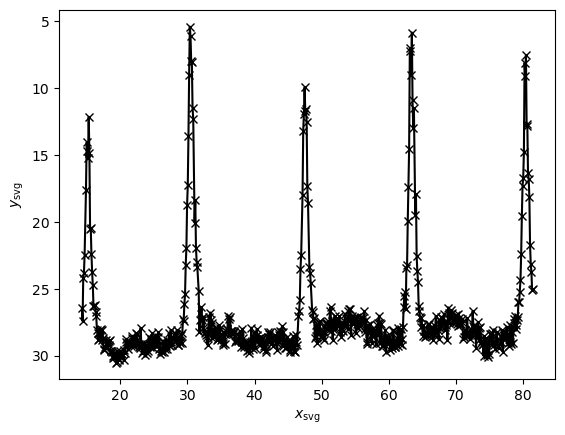

In [2]:
df = extract_curve('content/top/GSN-069.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_1 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_1 = np.array(df.sort_values(by='x_svg')['y_svg'])

plt.plot(x_sig_1, y_sig_1, 'kx-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 170 points

       x_svg       y_svg
0  4988.8050  230.965450
1  5254.1198  230.965450
2  5254.1198  126.602100
3  4988.8050  126.602100
4   122.4000   97.199992


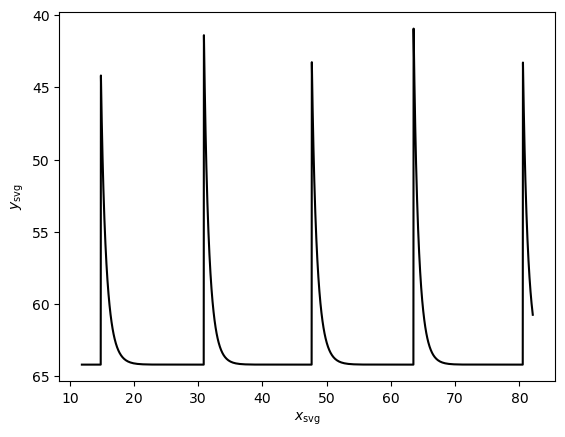

In [3]:
df = extract_curve('content/bot/GSN-069.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_1 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_1 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_1 = x_fit_1[y_fit_1 < 64.5]
y_fit_1 = y_fit_1[y_fit_1 < 64.5]
x_fit_1 = x_fit_1[y_fit_1 > 40]
y_fit_1 = y_fit_1[y_fit_1 > 40]

plt.plot(x_fit_1, y_fit_1, 'k-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 387 points

        x_svg       y_svg
0   23.001877   15.581984
1  695.489960   15.581984
2  695.489960  619.245310
3   23.001877  619.245310
4   -2.875148   77.403329


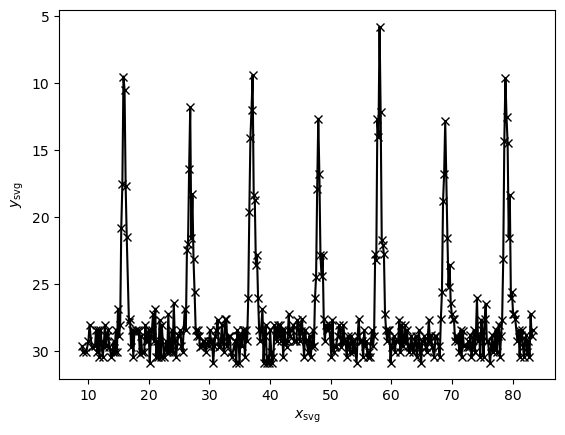

In [4]:
df = extract_curve('content/top/eRO-QPE2.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_2 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_2 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_2 = x_sig_2[y_sig_2 < 40]
y_sig_2 = y_sig_2[y_sig_2 < 40]
x_sig_2 = x_sig_2[y_sig_2 > 0]
y_sig_2 = y_sig_2[y_sig_2 > 0]
y_sig_2 = y_sig_2[x_sig_2 < 100]
x_sig_2 = x_sig_2[x_sig_2 < 100]

x_sig_2 = np.concatenate([x_sig_2[:66], x_sig_2[67:]])
y_sig_2 = np.concatenate([y_sig_2[:66], y_sig_2[67:]])

plt.plot(x_sig_2, y_sig_2, 'kx-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 235 points

        x_svg       y_svg
0   122.40007   97.200006
1   684.00007   97.200006
2   684.00007  318.109100
3   122.40007  318.109100
4  5756.27200  396.093320


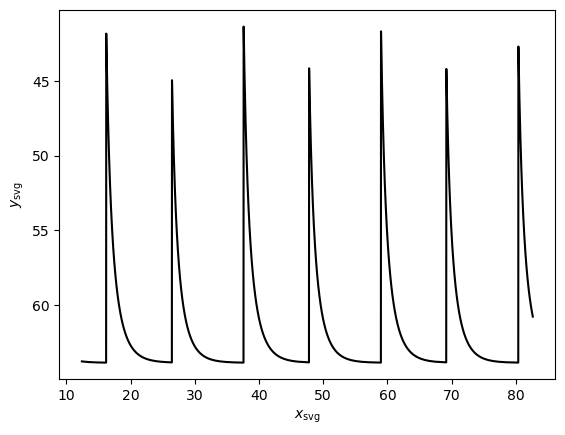

In [5]:
df = extract_curve('content/bot/eRO-QPE2.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_2 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_2 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_2 = x_fit_2[y_fit_2 < 65]
y_fit_2 = y_fit_2[y_fit_2 < 65]
x_fit_2 = x_fit_2[y_fit_2 > 40]
y_fit_2 = y_fit_2[y_fit_2 > 40]

plt.plot(x_fit_2, y_fit_2, 'k-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 461 points

        x_svg       y_svg
0   11.712505   17.831339
1  703.956880   17.831339
2  703.956880  618.672380
3   11.712505  618.672380
4   15.666914   23.273028


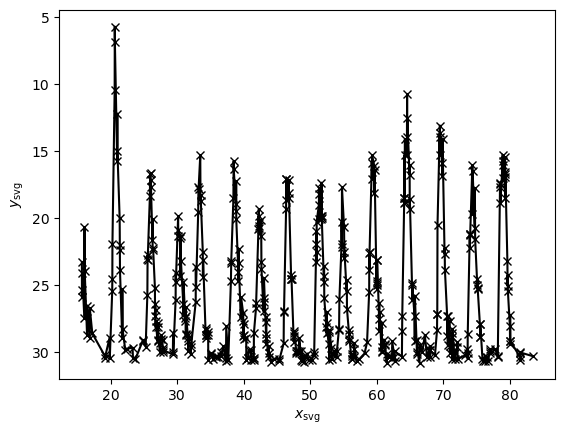

In [6]:
df = extract_curve('content/top/eRO-QPE1.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_3 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_3 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_3 = x_sig_3[y_sig_3 < 100]
y_sig_3 = y_sig_3[y_sig_3 < 100]
y_sig_3 = y_sig_3[x_sig_3 < 100]
x_sig_3 = x_sig_3[x_sig_3 < 100]
y_sig_3 = y_sig_3[x_sig_3 > 15]
x_sig_3 = x_sig_3[x_sig_3 > 15]

plt.plot(x_sig_3, y_sig_3, 'kx-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 391 points

        x_svg       y_svg
0   11.712505   17.831339
1  703.956880   17.831339
2  703.956880  618.672380
3   11.712505  618.672380
4   -1.464019   77.331715


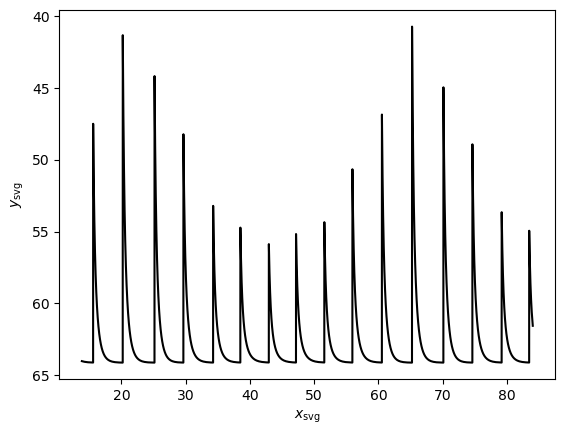

In [7]:
df = extract_curve('content/bot/eRO-QPE1.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_3 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_3 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_3 = x_fit_3[y_fit_3 < 65]
y_fit_3 = y_fit_3[y_fit_3 < 65]
x_fit_3 = x_fit_3[y_fit_3 > 40]
y_fit_3 = y_fit_3[y_fit_3 > 40]

plt.plot(x_fit_3, y_fit_3, 'k-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 466 points

        x_svg       y_svg
0   24.534178   12.759656
1  697.022470   12.759656
2  697.022470  622.067610
3   24.534178  622.067610
4  122.399950  362.290920


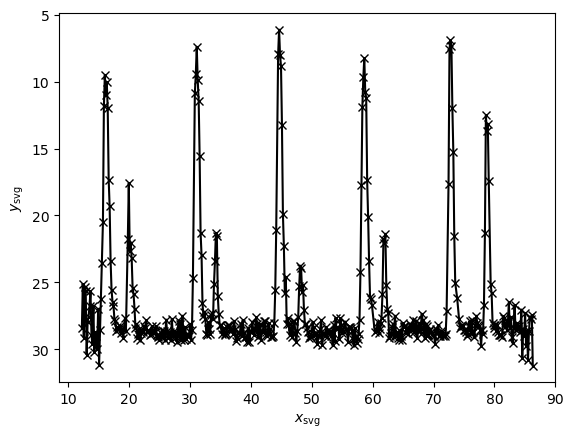

In [8]:
df = extract_curve('content/top/RX-J1302.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_4 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_4 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_4 = x_sig_4[y_sig_4 < 65]
y_sig_4 = y_sig_4[y_sig_4 < 65]
y_sig_4 = y_sig_4[x_sig_4 < 100]
x_sig_4 = x_sig_4[x_sig_4 < 100]

x_sig_4 = np.concatenate([x_sig_4[:77], x_sig_4[78:]])
y_sig_4 = np.concatenate([y_sig_4[:77], y_sig_4[78:]])

plt.plot(x_sig_4, y_sig_4, 'kx-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 253 points

        x_svg       y_svg
0   24.534178   12.759656
1  697.022470   12.759656
2  697.022470  622.067610
3   24.534178  622.067610
4   -0.000000    0.000004


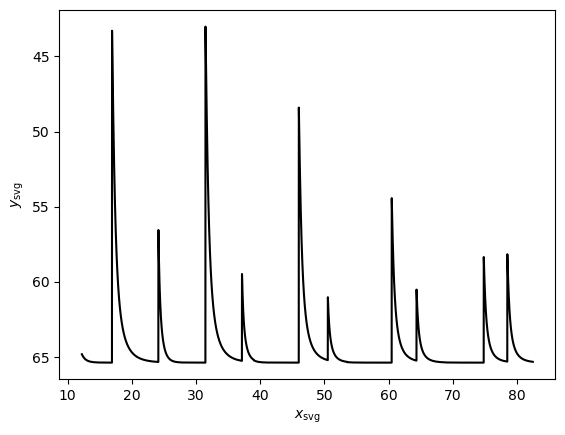

In [9]:
df = extract_curve('content/bot/RX-J1302.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_4 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_4 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_4 = x_fit_4[y_fit_4 < 65.5]
y_fit_4 = y_fit_4[y_fit_4 < 65.5]
x_fit_4 = x_fit_4[y_fit_4 > 40]
y_fit_4 = y_fit_4[y_fit_4 > 40]

plt.plot(x_fit_4, y_fit_4, 'k-')
plt.xlabel(r'$x_\text{svg}$')
plt.ylabel(r'$y_\text{svg}$')
plt.gca().invert_yaxis()
plt.show()
plt.close()

### Scale Axes

found 19 xticks and 7 yticks

       x_svg
0  14.262745
1  17.928415
2  21.594111
3  25.259807
4  28.925477


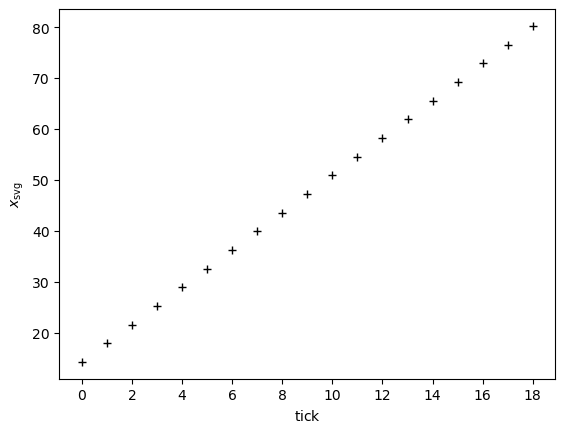

       y_svg
0   6.726361
1  10.388829
2  14.051295
3  17.713764
4  21.376230


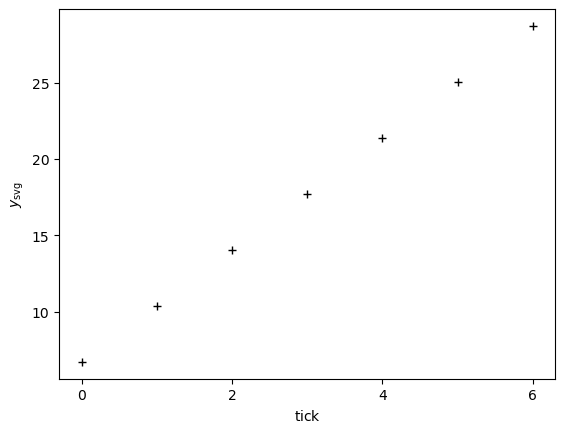

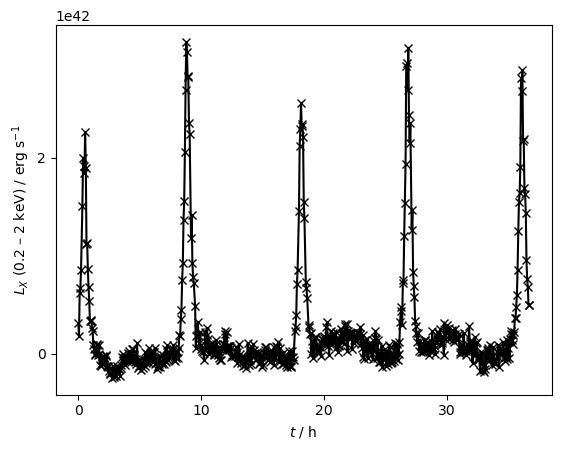

In [10]:
df_x, df_y = extract_axis_ticks('content/top/GSN-069.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_sig_1 = 0.0 + (x_sig_1 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_sig_1 = 1e42 * (3.0 + (y_sig_1 - yt[0]) * (3.0 - 2.0) / (yt[0] - yt[2]))

plt.plot(corr_x_sig_1, corr_y_sig_1, 'kx-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 35, 10))
plt.yticks(1e42 * np.arange(0, 3, 2))
plt.show()
plt.close()

found 19 xticks and 7 yticks

       x_svg
0  14.262745
1  17.928415
2  21.594111
3  25.259807
4  28.925477


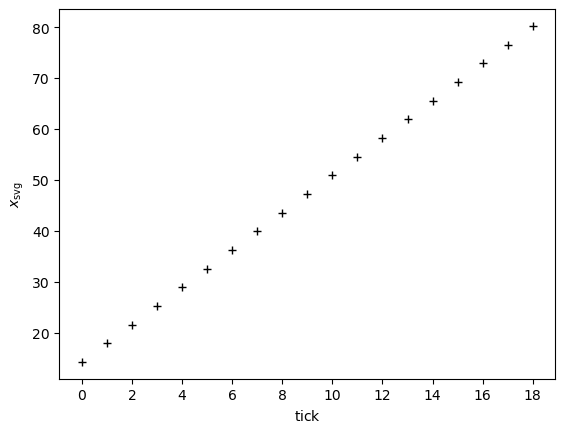

       y_svg
0  37.288113
1  41.770710
2  46.253308
3  50.735906
4  55.218506


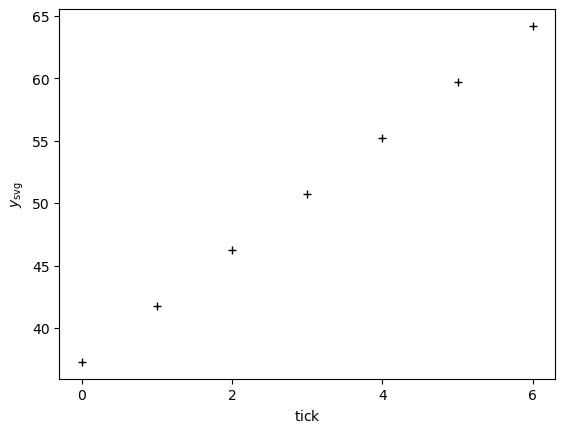

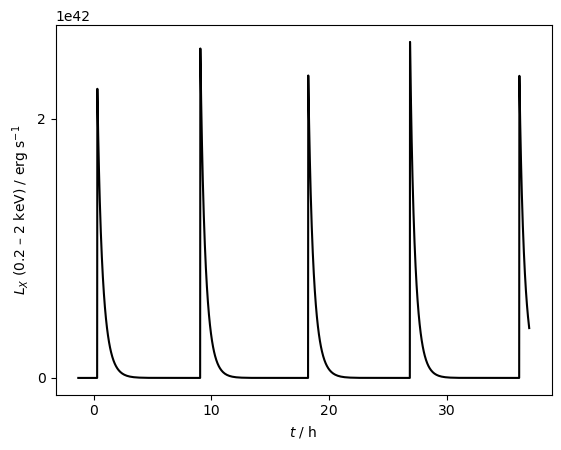

In [11]:
df_x, df_y = extract_axis_ticks('content/bot/GSN-069.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_fit_1 = 0.0 + (x_fit_1 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_fit_1 = 1e42 * (3.0 + (y_fit_1 - yt[0]) * (3.0 - 2.0) / (yt[0] - yt[2]))

plt.plot(corr_x_fit_1, corr_y_fit_1, 'k-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 35, 10))
plt.yticks(1e42 * np.arange(0, 3, 2))
plt.show()
plt.close()

found 17 xticks and 14 yticks

       x_svg
0  13.291144
1  17.624347
2  21.957549
3  26.290751
4  30.623953


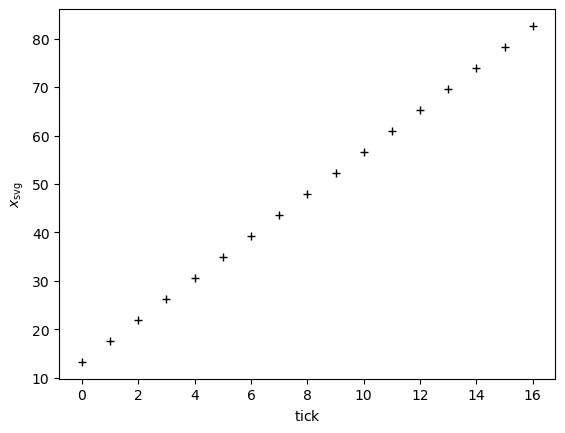

       y_svg
0   4.941582
1   6.989265
2   9.036948
3  11.084632
4  13.132315


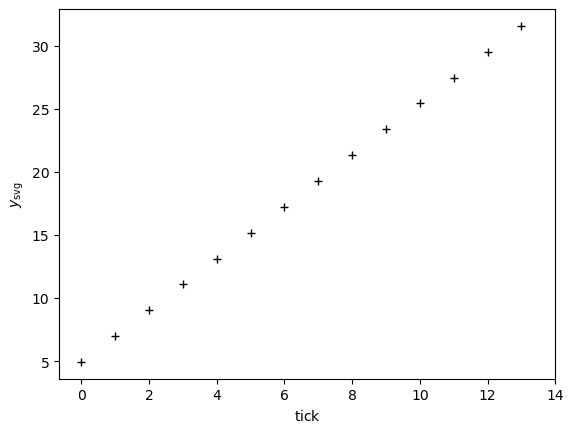

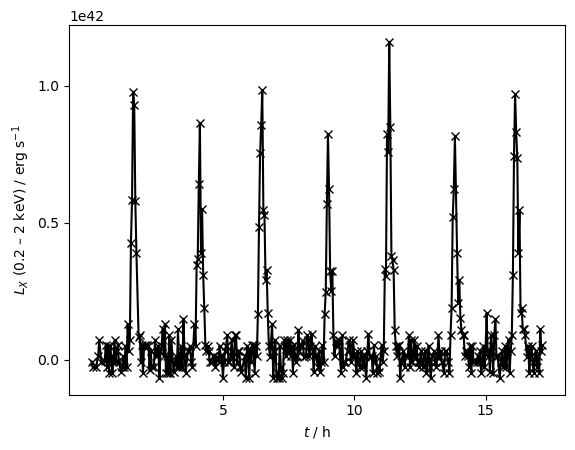

In [12]:
df_x, df_y = extract_axis_ticks('content/top/eRO-QPE2.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_sig_2 = 1.0 + (x_sig_2 - xt[0]) * (1.0 - 5.0) / (xt[0] - xt[4])
corr_y_sig_2 = 1e42 * (1.0 + (y_sig_2 - yt[2]) * (1.0 - 0.5) / (yt[2] - yt[7]))

plt.plot(corr_x_sig_2, corr_y_sig_2, 'kx-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(5, 17.5, 5))
plt.yticks(1e42 * np.arange(0, 1.25, 0.5))
plt.show()
plt.close()

found 17 xticks and 8 yticks

       x_svg
0  13.291144
1  17.624347
2  21.957549
3  26.290751
4  30.623953


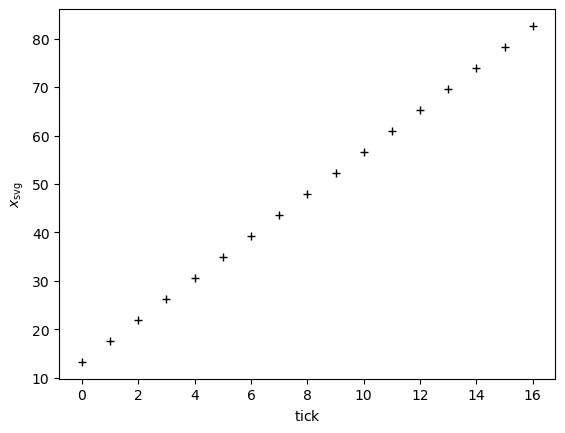

       y_svg
0  39.388538
1  42.883829
2  46.379121
3  49.874413
4  53.369704


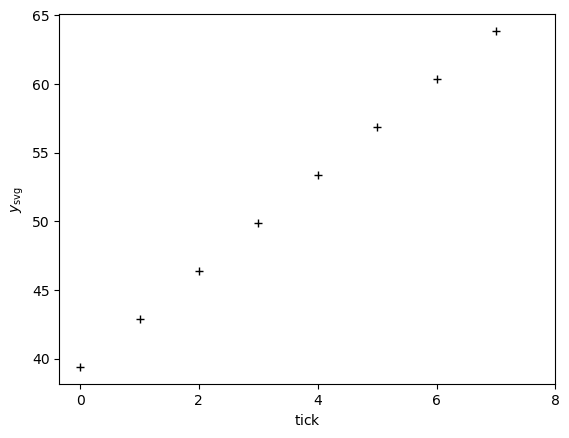

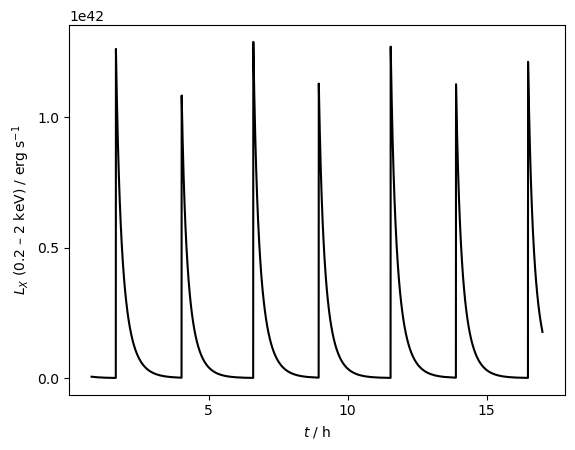

In [13]:
df_x, df_y = extract_axis_ticks('content/bot/eRO-QPE2.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_fit_2 = 1.0 + (x_fit_2 - xt[0]) * (1.0 - 5.0) / (xt[0] - xt[4])
corr_y_fit_2 = 1e42 * (0.0 + (y_fit_2 - yt[7]) * (1.0 - 0.0) / (yt[2] - yt[7]))

plt.plot(corr_x_fit_2, corr_y_fit_2, 'k-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(5, 17.5, 5))
plt.yticks(1e42 * np.arange(0, 1.25, 0.5))
plt.show()
plt.close()

found 15 xticks and 9 yticks

       x_svg
0  15.666914
1  20.550244
2  25.433575
3  30.316905
4  35.200236


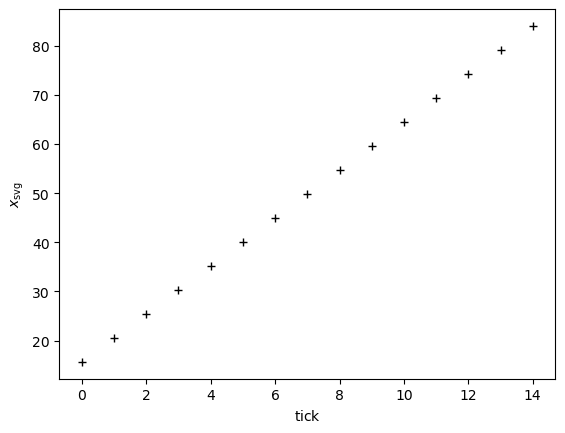

       y_svg
0   7.166685
1  10.121978
2  13.077270
3  16.032562
4  18.987855


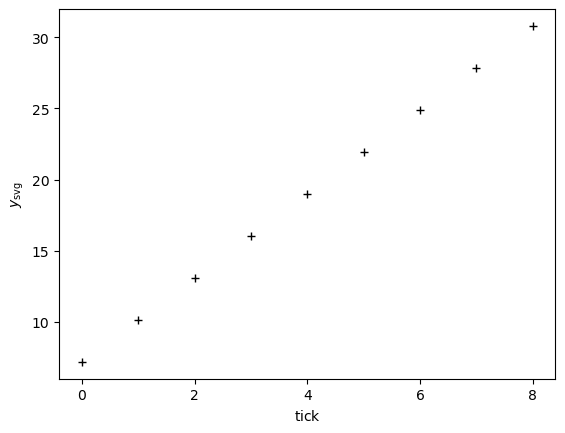

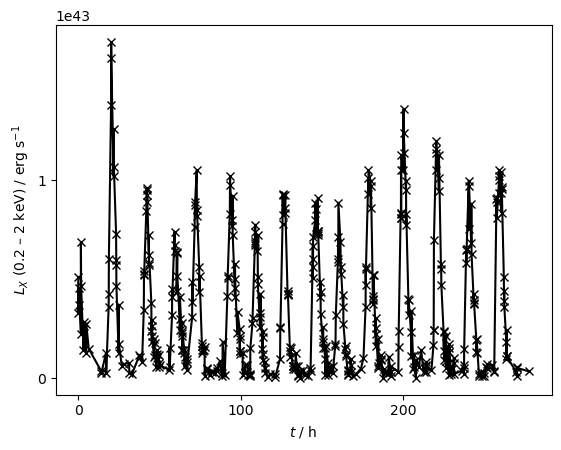

In [14]:
df_x, df_y = extract_axis_ticks('content/top/eRO-QPE1.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_sig_3 = 0.0 + (x_sig_3 - xt[0]) * (0.0 - 100.0) / (xt[0] - xt[5])
corr_y_sig_3 = 1e43 * (1.0 + (y_sig_3 - yt[3]) * (1.0 - 0.0) / (yt[3] - yt[8]))

plt.plot(corr_x_sig_3, corr_y_sig_3, 'kx-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 250, 100))
plt.yticks(1e43 * np.arange(0, 1.5, 1))
plt.show()
plt.close()

found 15 xticks and 11 yticks

       x_svg
0  15.666914
1  20.550244
2  25.433575
3  30.316905
4  35.200236


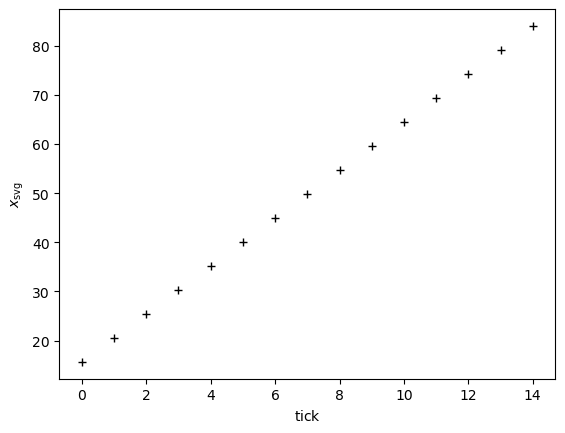

       y_svg
0  37.569276
1  40.224353
2  42.879431
3  45.534507
4  48.189584


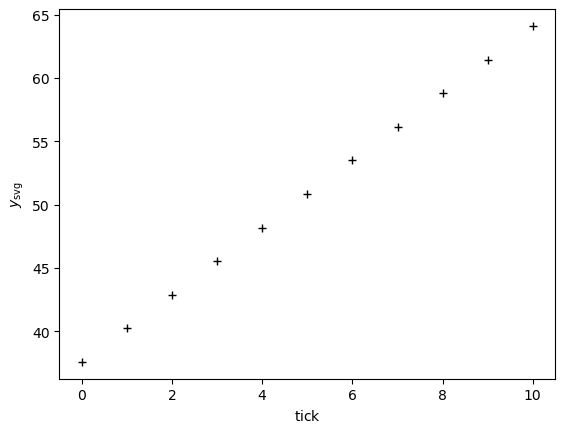

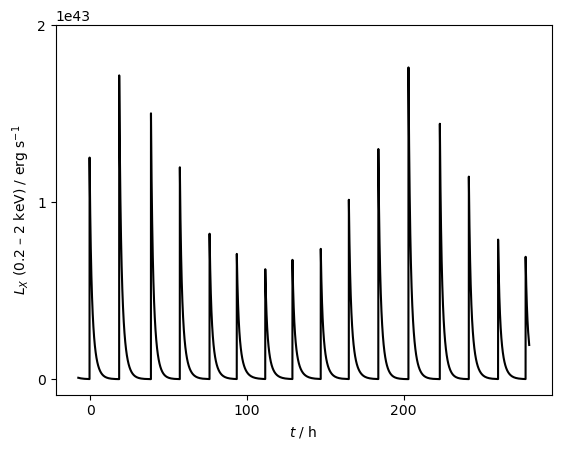

In [15]:
df_x, df_y = extract_axis_ticks('content/bot/eRO-QPE1.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_fit_3 = 0.0 + (x_fit_3 - xt[0]) * (0.0 - 100.0) / (xt[0] - xt[5])
corr_y_fit_3 = 1e43 * (0.0 + (y_fit_3 - yt[10]) * (1.0 - 0.0) / (yt[5] - yt[10]))

plt.plot(corr_x_fit_3, corr_y_fit_3, 'k-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 250, 100))
plt.yticks(1e43 * np.arange(0, 2.5, 1))
plt.show()
plt.close()

found 16 xticks and 13 yticks

       x_svg
0  12.232865
1  16.761765
2  21.290664
3  25.819563
4  30.348463


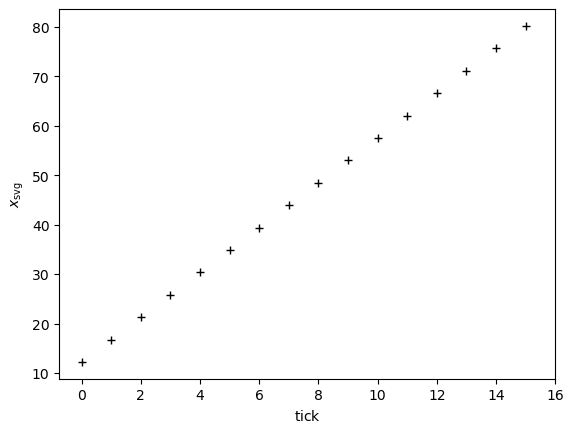

       y_svg
0   5.765537
1   7.851962
2   9.938384
3  12.024806
4  14.111231


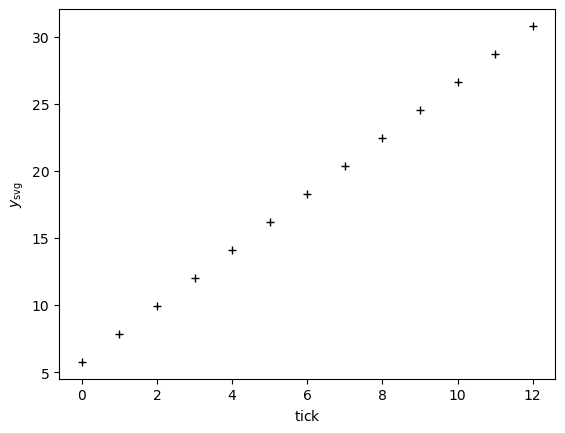

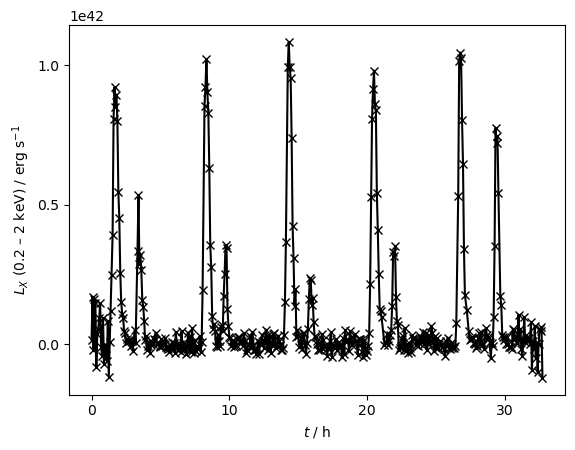

In [16]:
df_x, df_y = extract_axis_ticks('content/top/RX-J1302.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_sig_4 = 0.0 + (x_sig_4 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_sig_4 = 1e42 * (1.0 + (y_sig_4 - yt[1]) * (1.0 - 0.5) / (yt[1] - yt[6]))

plt.plot(corr_x_sig_4, corr_y_sig_4, 'kx-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 35, 10))
plt.yticks(1e42 * np.arange(0, 1.25, 0.5))
plt.show()
plt.close()

found 16 xticks and 12 yticks

       x_svg
0  12.232865
1  16.761765
2  21.290664
3  25.819563
4  30.348463


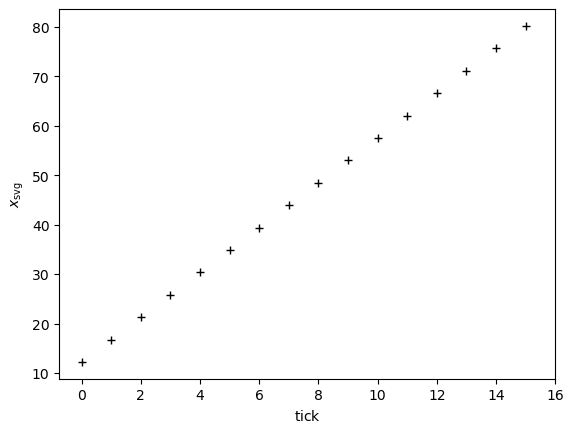

       y_svg
0  40.275717
1  42.557767
2  44.839817
3  47.121867
4  49.403917


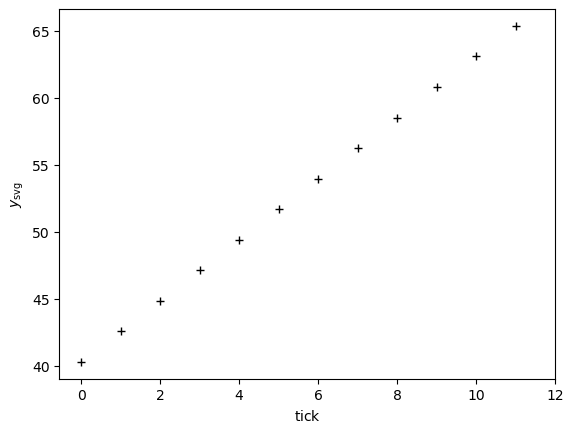

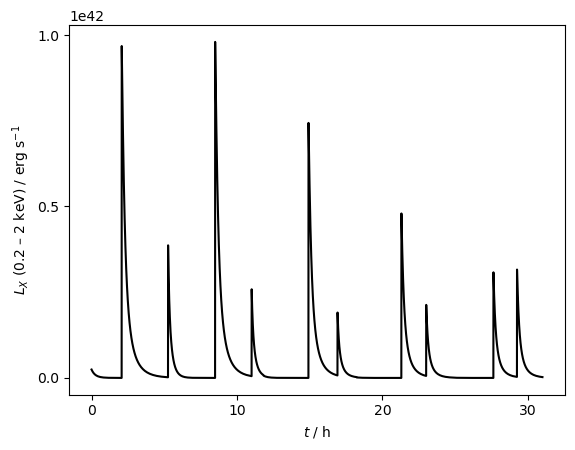

In [17]:
df_x, df_y = extract_axis_ticks('content/bot/RX-J1302.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$x_\text{svg}$')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'k+')
plt.xlabel(r'$\text{tick}$')
plt.ylabel(r'$y_\text{svg}$')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_fit_4 = 0.0 + (x_fit_4 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_fit_4 = 1e42 * (1.0 + (y_fit_4 - yt[1]) * (1.0 - 0.5) / (yt[1] - yt[6]))

plt.plot(corr_x_fit_4, corr_y_fit_4, 'k-')
plt.xlabel(r'$t$ / h')
plt.ylabel(r'$L_X$ (0.2 – 2 keV) / erg s$^{-1}$')
plt.xticks(np.arange(0, 35, 10))
plt.yticks(1e42 * np.arange(0, 1.25, 0.5))
plt.show()
plt.close()

### Write Data

In [18]:
with open('content/GSN-069.txt', 'w') as f:
    f.write('### GSN-069 ###\n\n# sig_time / h # sig_powr / erg/s # fit_time / h # fit_powr / erg/s #\n\n')
    k = 0
    while k < len(corr_x_fit_1):
        f.write(f'{corr_x_sig_1[k]}   {corr_y_sig_1[k]}   {corr_x_fit_1[k]}   {corr_y_fit_1[k]}\n')
        k += 1
    while k < len(corr_x_sig_1):
        f.write(f'{corr_x_sig_1[k]}   {corr_y_sig_1[k]}\n')
        k += 1

In [19]:
with open('content/eRO-QPE2.txt', 'w') as f:
    f.write('### eRO-QPE2 ###\n\n# sig_time / h # sig_powr / erg/s # fit_time / h # fit_powr / erg/s #\n\n')
    k = 0
    while k < len(corr_x_fit_2):
        f.write(f'{corr_x_sig_2[k]}   {corr_y_sig_2[k]}   {corr_x_fit_2[k]}   {corr_y_fit_2[k]}\n')
        k += 1
    while k < len(corr_x_sig_2):
        f.write(f'{corr_x_sig_2[k]}   {corr_y_sig_2[k]}\n')
        k += 1

In [20]:
with open('content/eRO-QPE1.txt', 'w') as f:
    f.write('### eRO-QPE1 ###\n\n# sig_time / h # sig_powr / erg/s # fit_time / h # fit_powr / erg/s #\n\n')
    k = 0
    while k < len(corr_x_fit_3):
        f.write(f'{corr_x_sig_3[k]}   {corr_y_sig_3[k]}   {corr_x_fit_3[k]}   {corr_y_fit_3[k]}\n')
        k += 1
    while k < len(corr_x_sig_3):
        f.write(f'{corr_x_sig_3[k]}   {corr_y_sig_3[k]}\n')
        k += 1

In [21]:
with open('content/RX-J1302.txt', 'w') as f:
    f.write('### RX-J1302 ###\n\n# sig_time / h # sig_powr / erg/s # fit_time / h # fit_powr / erg/s #\n\n')
    k = 0
    while k < len(corr_x_fit_4):
        f.write(f'{corr_x_sig_4[k]}   {corr_y_sig_4[k]}   {corr_x_fit_4[k]}   {corr_y_fit_4[k]}\n')
        k += 1
    while k < len(corr_x_sig_4):
        f.write(f'{corr_x_sig_4[k]}   {corr_y_sig_4[k]}\n')
        k += 1